# Method 1

In [1]:
import numpy as np
from scipy.stats import norm 
from scipy.optimize import brentq 

# hyperparameters
k = 0.15; sigma_r = 0.012; theta = 0.05; r0 = 0.038


def B(t1, t2):
    return 1/k * (1 - np.exp(-k * (t2-t1)))

def A(t1, t2):
    first_term = (theta - sigma_r**2/(2 * k**2)) * (B(t1, t2) - (t2-t1))
    second_term = sigma_r**2/(4*k) * B(t1, t2)**2
    return np.exp(first_term - second_term)

def P0T(t):
    return A(0.0, t) * np.exp(-B(0.0, t) * r0)

def P_T1(T1, T, r):
    return A(T1, T) * np.exp(-B(T1, T) * r)


def sigma_tilde(t1, t2):
    sqrt = (1 - np.exp(-2*k*t1))/(2*k)
    return sigma_r * np.sqrt(sqrt) * B(t1, t2)

def h_func(t1, t2, K):
    sig = sigma_tilde(t1, t2)
    return (1/sig) * np.log(P0T(t2)/(P0T(t1)*K)) + sig/2

def ZBP(t1, t2, K):
    sig = sigma_tilde(t1, t2)
    h = h_func(t1, t2, K)
    return K * P0T(t1) * norm.cdf(-h + sig) - P0T(t2) * norm.cdf(-h)

# finding r hat such that we exercise if r > r hat, given by f_rhat = 0 
def f_rhat(r_hat, T1, taus, coupons, K):
    return sum(c * P_T1(T1, T1+tau, r_hat) for c, tau in zip(coupons, taus)) - K 


T1 = 0.5 # 6 months
taus = np.array([0.5, 1.0, 1.5, 2.0]) # T1 + tau
coupons = np.array([0.02, 0.02, 0.02, 1.02]) # cf 
K = 1.0 


r_hat = brentq(f_rhat, -0.05, 0.20, args=(T1, taus, coupons, K))
print(f'$r_hat$ is given by {r_hat:.4f}')


K_i = np.array([P_T1(T1, T1+tau, r_hat) for tau in taus])
# coupon-bond put price 
zcb_put_price = sum(c * ZBP(T1, T1+tau, K_i) for c, tau, K_i in zip(coupons, taus, K_i))

print(f"almost-analytical option price : {zcb_put_price:.6f}")

$r_hat$ is given by 0.0381
almost-analytical option price : 0.005985


# Method 2

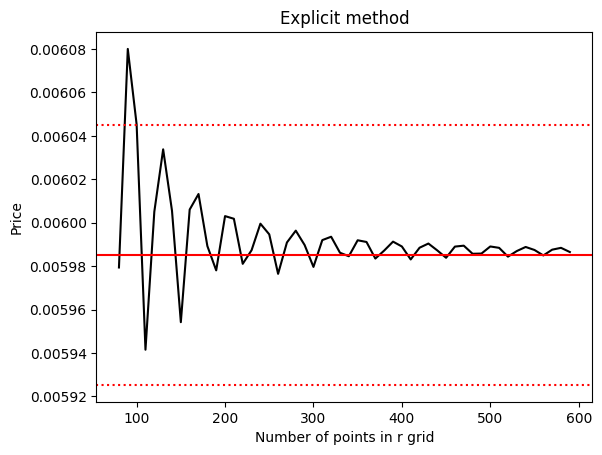

In [2]:


import numpy as np
import matplotlib.pyplot as plt


T1 = 0.5
r_min = 0.0
r_max = 0.30
N = 800                    

J_values = np.arange(80, 600, 10)
prices_fd = []

for J in J_values:
    dr = (r_max - r_min) / J
    r_grid = np.linspace(r_min, r_max, J+1)

    dt = T1 / N
    t_grid = np.linspace(0.0, T1, N+1)

    # V[n,j] ~ V(t_n, r_j)
    V = np.zeros((N+1, J+1))

    for j, rj in enumerate(r_grid):
        bond_T1 = sum(c * P_T1(T1, T1 + tau, rj)
                      for c, tau in zip(coupons, taus))
        V[-1, j] = max(K - bond_T1, 0.0)

    # explicit scheme
    for n in range(N-1, -1, -1):
        t = t_grid[n]

        # boundary conditions
        V[n, 0]  = 0.0
        #estimation of r at T1
        r_T1 = r_max*np.exp(-k*(T1 - t)) + theta*(1 - np.exp(-k*(T1 - t)))
        bond_T1 = sum(c * P_T1(T1, T1 + tau, r_T1) for c, tau in zip(coupons, taus))
        #print(f"Bond for r max = {bond_T1}")
        #We always exercse for r_max
        V[n, -1] =(K -bond_T1)* P_T1(t, T1, r_max)

        r_inner = r_grid[1:-1]
        A_j = (sigma_r**2 * dt/(2*dr**2) - k*(theta - r_inner)*dt/(2*dr))
        B_j = 1.0 - (sigma_r**2 * dt/dr**2 + r_inner*dt)
        C_j = (sigma_r**2 * dt/(2*dr**2) + k*(theta - r_inner)*dt/(2*dr))

        V[n, 1:-1] = (A_j * V[n+1, 0:-2] + B_j * V[n+1, 1:-1] + C_j * V[n+1, 2:])

    # price at t=0, r=r0 (interpolation)
    price_fd_explicit = np.interp(r0, r_grid, V[0, :])
    prices_fd.append(price_fd_explicit)


# plot 
prices_fd = np.array(prices_fd)

plt.figure()
plt.plot(J_values, prices_fd, 'k-') 

plt.axhline(zcb_put_price, linestyle='-',  color='r')   # analytical
plt.axhline(zcb_put_price*1.01, color='r', linestyle = ':')   # +1%
plt.axhline(zcb_put_price*0.99, color='r', linestyle = ':')   # -1%

plt.xlabel('Number of points in r grid')
plt.ylabel('Price')
plt.title('Explicit method')

plt.show()


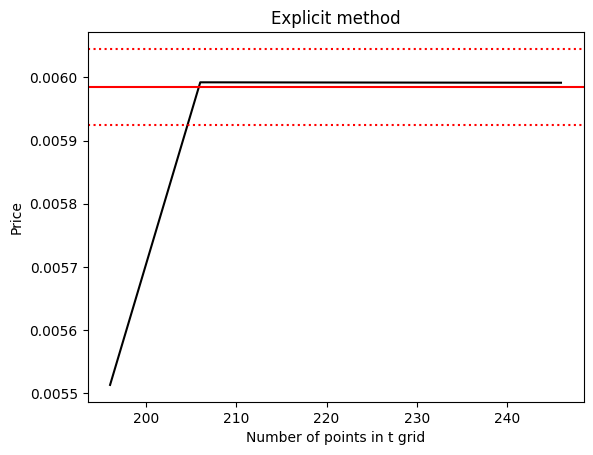

In [3]:
import numpy as np
import matplotlib.pyplot as plt


T1 = 0.5
r_min = 0.0
r_max = 0.30
#N = 800                    

J = 500
N_values = np.arange(196, 256, 10)
prices_fd = []

for N in N_values:
    dr = (r_max - r_min) / J
    r_grid = np.linspace(r_min, r_max, J+1)

    dt = T1 / N
    t_grid = np.linspace(0.0, T1, N+1)

    # V[n,j] ~ V(t_n, r_j)
    V = np.zeros((N+1, J+1))

    for j, rj in enumerate(r_grid):
        bond_T1 = sum(c * P_T1(T1, T1 + tau, rj)
                      for c, tau in zip(coupons, taus))
        V[-1, j] = max(K - bond_T1, 0.0)

    # explicit scheme
    for n in range(N-1, -1, -1):
        t = t_grid[n]

        # boundary conditions
        V[n, 0]  = 0.0
        #estimation of r at T1 using evolution under vasicek
        r_T1 = r_max*np.exp(-k*(T1 - t)) + theta*(1 - np.exp(-k*(T1 - t)))
        bond_T1 = sum(c * P_T1(T1, T1 + tau, r_T1) for c, tau in zip(coupons, taus))
        #print(f"Bond for r max = {bond_T1}")
        #We always exercse for r_max
        V[n, -1] =(K -bond_T1)* P_T1(t, T1, r_max)

        r_inner = r_grid[1:-1]
        A_j = (sigma_r**2 * dt/(2*dr**2) - k*(theta - r_inner)*dt/(2*dr))
        B_j = 1.0 - (sigma_r**2 * dt/dr**2 + r_inner*dt)
        C_j = (sigma_r**2 * dt/(2*dr**2) + k*(theta - r_inner)*dt/(2*dr))

        V[n, 1:-1] = (A_j * V[n+1, 0:-2] + B_j * V[n+1, 1:-1] + C_j * V[n+1, 2:])

    # price at t=0, r=r0 (interpolation)
    price_fd_explicit = np.interp(r0, r_grid, V[0, :])
    prices_fd.append(price_fd_explicit)


# plot 
prices_fd = np.array(prices_fd)

plt.figure()
plt.plot(N_values, prices_fd, 'k-') 

plt.axhline(zcb_put_price, linestyle='-',  color='r')   # analytical
plt.axhline(zcb_put_price*1.01, color='r', linestyle = ':')   # +1%
plt.axhline(zcb_put_price*0.99, color='r', linestyle = ':')   # -1%

plt.xlabel('Number of points in t grid')
plt.ylabel('Price')
plt.title('Explicit method')

plt.show()

# Method 3

In [4]:
import numpy as np
from numpy.linalg import solve

def price_cn(J=400, N=800):
    r_min = 0.0
    r_max = 0.30

    dr = (r_max - r_min) / J
    r_grid = np.linspace(r_min, r_max, J+1)

    dt = T1 / N
    t_grid = np.linspace(0.0, T1, N+1)
    V = np.zeros((N+1, J+1))

    for j, rj in enumerate(r_grid):
        bond_T1 = sum(c * P_T1(T1, T1 + tau, rj)
                      for c, tau in zip(coupons, taus))
        V[-1, j] = max(K - bond_T1, 0.0)

    r_inner = r_grid[1:-1]   

    #coeffs derived in our homework
    a1 = (dt/(4*dr))  * (sigma_r**2 / dr - k * (theta - r_inner))  
    a2 =  (dt/(4*dr))  * (-sigma_r**2 / dr + k * (theta - r_inner)) 
    b1 =  - 1 - dt*(sigma_r**2 /(2*dr**2) + r_inner/2)
    b2 =  - 1 + dt*(sigma_r**2 /(2*dr**2) + r_inner/2) 
    c1 = (dt/(4*dr))  * (sigma_r**2 / dr + k * (theta - r_inner)) 
    c2 = -(dt/(4*dr))  * (sigma_r**2 / dr + k * (theta - r_inner)) 

    #Matrixes sur that A1 V^n = A2 V^n+1 + b
    A1 = np.diag(b1)
    A1 += np.diag(a1[1:], k =-1)
    A1 += np.diag(c1[:-1], k =1)

    A2 = np.diag(b2)
    A2 += np.diag(a2[1:], k =-1)
    A2 += np.diag(c2[:-1], k =1)

    gamma = -dt/(4*dr) * (sigma_r ** 2 / dr + k*(theta - r_max)) 
 

    for n in range(N-1, -1, -1):     # n = N-1,...,0
        t_n = t_grid[n]
        t_np1 = t_grid[n+1]

        # boundary conditions at t_n and t_{n+1}
        r_T1_t = r_max*np.exp(-k*(T1 - t_n)) + theta*(1 - np.exp(-k*(T1 - t_n)))
        r_T1_tp1 = r_T1 = r_max*np.exp(-k*(T1 - t_np1)) + theta*(1 - np.exp(-k*(T1 - t_np1)))
        bond_T1 = sum(c * P_T1(T1, T1 + tau, r_T1_t) for c, tau in zip(coupons, taus))
        bond_T1_p1 = sum(c * P_T1(T1, T1 + tau, r_T1_tp1) for c, tau in zip(coupons, taus))
        V[n,0] = 0.0
        V[n,-1] = (K -  bond_T1)  * A(t_n,  T1) * np.exp(-B(t_n,  T1) * r_max)
        V[n+1, 0] = 0.0
        V[n+1,-1] = (K - bond_T1_p1) * A(t_np1, T1) * np.exp(-B(t_np1, T1) * r_max)

        rhs = A2 @ V[n+1,1:-1]
        #adding b 
        rhs[-1] += gamma *(V[n+1, -1] + V[n,-1])
    
        V_inner_n = solve(A1, rhs)
        V[n, 1:J] = V_inner_n

    price_cn_0 = np.interp(r0, r_grid, V[0, :])
    return price_cn_0

In [5]:
price_cn_single = price_cn(J=400, N=800)
print(f"CN price (J=400,N=800) = {price_cn_single:.8f}")
print(f"Relative error = {(price_cn_single/zcb_put_price - 1)*100:.4f}%")

CN price (J=400,N=800) = 0.00598799
Relative error = 0.0477%


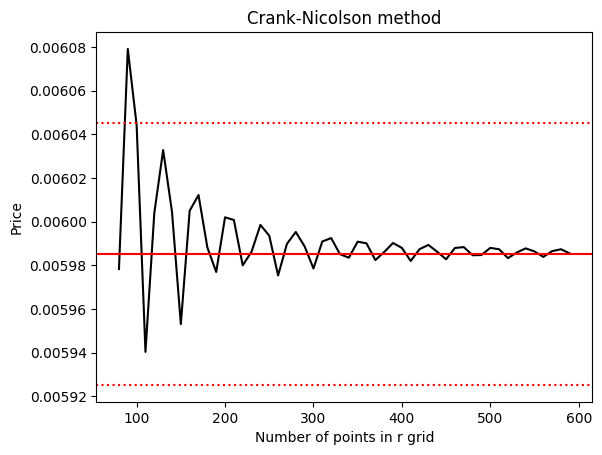

In [6]:
import matplotlib.pyplot as plt

# choose same range of J as before
J_values = np.arange(80, 600, 10)
N = 800  


prices_cn = []

for J in J_values:
    p = price_cn(J=J, N=N)
    prices_cn.append(p)

prices_cn = np.array(prices_cn)

plt.figure()
plt.plot(J_values, prices_cn, 'k-')

plt.axhline(zcb_put_price, color='r')       # analytical
plt.axhline(zcb_put_price*1.01, color='r', linestyle = ':')       # +1%
plt.axhline(zcb_put_price*0.99, color='r', linestyle = ":")       # -1%

plt.xlabel('Number of points in r grid')
plt.ylabel('Price')
plt.title('Crank-Nicolson method')

plt.show()

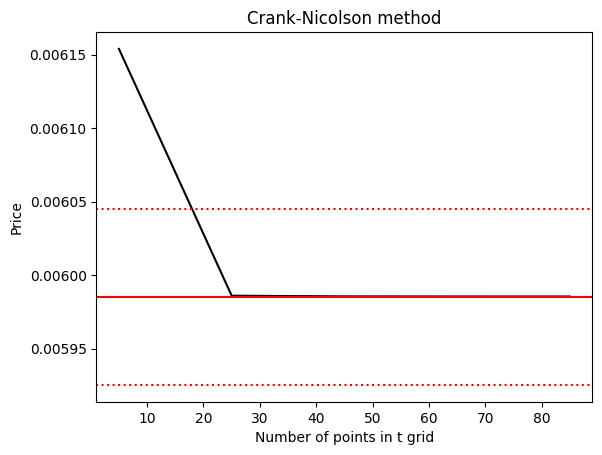

In [7]:
N_values = np.arange(5, 100, 20)
J_values = 500



prices_cn = []

for N in N_values:
    p = price_cn(J=J, N=N)
    prices_cn.append(p)

prices_cn = np.array(prices_cn)

plt.figure()
plt.plot(N_values, prices_cn, 'k-')

plt.axhline(zcb_put_price, color='r')       # analytical
plt.axhline(zcb_put_price*1.01, color='r', linestyle = ':')       # +1%
plt.axhline(zcb_put_price*0.99, color='r', linestyle = ":")       # -1%

plt.xlabel('Number of points in t grid')
plt.ylabel('Price')
plt.title('Crank-Nicolson method')

plt.show()